# Trem em Linha Reta — Filtro de Kalman

Este notebook aplica o **Filtro de Kalman** para estimar a posição e a velocidade de um trem
em movimento retilíneo e uniforme, a partir de medições ruidosas de posição.

O modelo assume velocidade constante com perturbação de processo (aceleração aleatória),
e o filtro combina previsão cinemática com atualização baseada nas medições.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos Dados

| Coluna | Descrição |
|---|---|
| `n` | Número do passo de tempo (1 a 20) |
| `pos_verdadeira_m` | Posição verdadeira do trem em metros |
| `medicao_pos_m` | Medição ruidosa da posição em metros |

In [2]:
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemploA_trem.csv"

df = pd.read_csv(CAMINHO)
df

,n,pos_verdadeira_m,medicao_pos_m
0,1,25.0,17.069
1,2,50.0,52.406
2,3,75.0,56.037
3,4,100.0,113.958
4,5,125.0,131.383
5,6,150.0,147.080
6,7,175.0,171.881
7,8,200.0,203.038
8,9,225.0,222.323
9,10,250.0,247.741


## 3. Modelo de Estados

O trem é modelado pelo sistema:

$$\mathbf{x}_k = \mathbf{F}\,\mathbf{x}_{k-1} + \mathbf{w}_k$$
$$z_k = \mathbf{H}\,\mathbf{x}_k + v_k$$

onde:

- $\mathbf{x}_k = [p_k, v_k]^T$ — vetor de estados (posição, velocidade)
- $z_k$ — medição ruidosa da posição
- $\mathbf{w}_k \sim \mathcal{N}(0, \mathbf{Q})$ — ruído de processo
- $v_k \sim \mathcal{N}(0, R)$ — ruído de medição

### Matrizes do Sistema

$$\mathbf{F} = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}, \quad \mathbf{H} = \begin{bmatrix} 1 & 0 \end{bmatrix}$$

### Covariâncias de Ruído

O ruído de processo é modelado como aceleração aleatória com desvio padrão $a_s$:

$$\mathbf{Q} = a_s^2 \begin{bmatrix} \frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} \\ \frac{\Delta t^3}{2} & \Delta t^2 \end{bmatrix}$$

O ruído de medição tem variância $R = \sigma_m^2$.

## 4. Parâmetros do Filtro

In [3]:
# Medição ruidosa (entrada do filtro)
medicoes = df["medicao_pos_m"].to_numpy()

# Intervalo de amostragem
dt = 1.0

# Matriz de transição de estados (modelo de velocidade constante)
F = np.array([[1, dt],
              [0, 1]])

# Matriz de observação (medimos apenas posição)
H = np.array([[1, 0]])

# Covariância do ruído de medição
R = np.array([[100.0]])

# Parâmetro de ruído de processo (aceleração aleatória)
a_s = 0.5
Q = a_s**2 * np.array([[dt**4 / 4, dt**3 / 2],
                        [dt**3 / 2, dt**2]])

# Estado inicial e covariância
x = np.array([0.0, 20.0])  # posição = 0 m, velocidade = 20 m/s
P = np.diag([100.0, 100.0])

# Matriz identidade (2×2)
I2 = np.eye(2)

### Tabela de Parâmetros

| Parâmetro | Valor | Significado |
|---|---|---|
| $\Delta t$ | 1 s | Intervalo entre amostras |
| $\mathbf{F}$ | $\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$ | Transição de estados |
| $\mathbf{H}$ | $\begin{bmatrix} 1 & 0 \end{bmatrix}$ | Observação (mede posição) |
| $R$ | 100 | Variância do ruído de medição [m²] |
| $a_s$ | 0.5 | Desvio padrão da aceleração de processo [m/s²] |
| $\mathbf{x}_0$ | $[0, 20]^T$ | Estado inicial (posição, velocidade) |
| $\mathbf{P}_0$ | $\text{diag}(100, 100)$ | Covariância inicial (alta incerteza) |

## 5. Execução do Filtro de Kalman

Para cada medição $z_k$, o filtro executa:

### Previsão
$$\hat{\mathbf{x}}_k^- = \mathbf{F}\,\hat{\mathbf{x}}_{k-1}^+$$
$$\mathbf{P}_k^- = \mathbf{F}\,\mathbf{P}_{k-1}^+\,\mathbf{F}^T + \mathbf{Q}$$

### Atualização
$$\mathbf{K}_k = \mathbf{P}_k^-\,\mathbf{H}^T\left(\mathbf{H}\,\mathbf{P}_k^-\,\mathbf{H}^T + R\right)^{-1}$$
$$\hat{\mathbf{x}}_k^+ = \hat{\mathbf{x}}_k^- + \mathbf{K}_k\left(z_k - \mathbf{H}\,\hat{\mathbf{x}}_k^-\right)$$
$$\mathbf{P}_k^+ = \left(\mathbf{I} - \mathbf{K}_k\,\mathbf{H}\right)\mathbf{P}_k^-\left(\mathbf{I} - \mathbf{K}_k\,\mathbf{H}\right)^T + \mathbf{K}_k\,R\,\mathbf{K}_k^T$$

In [4]:
N = len(medicoes)
historico_x = np.zeros((N, 2))  # estados estimados (posição, velocidade)
historico_P = np.zeros((N, 2, 2))  # covariâncias

for k, z in enumerate(medicoes):
    # --- Previsão ---
    x = F @ x
    P = F @ P @ F.T + Q

    # --- Atualização ---
    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)
    x = x + K @ (np.array([z]) - H @ x)
    P = (I2 - K @ H) @ P @ (I2 - K @ H).T + K @ R @ K.T

    # Armazena resultado deste passo
    historico_x[k] = x
    historico_P[k] = P

print(f"Velocidade estimada final: {x[1]:.4f} m/s")
print(f"Posição estimada final:    {x[0]:.4f} m")

Velocidade estimada final: 24.3369 m/s
Posição estimada final:    496.1081 m


## 6. Métricas Estatísticas

Comparação entre a posição estimada pelo filtro e a posição verdadeira.

In [5]:
pos_verdadeira = df["pos_verdadeira_m"].to_numpy()
pos_estimada = historico_x[:, 0]
residuos = pos_estimada - pos_verdadeira

rmse_filtro = np.sqrt(np.mean(residuos**2))
mae_filtro = np.mean(np.abs(residuos))
erro_max_filtro = np.max(np.abs(residuos))
vies_filtro = np.mean(residuos)

# Comparação com as medições brutas
residuos_med = medicoes - pos_verdadeira
rmse_med = np.sqrt(np.mean(residuos_med**2))
mae_med = np.mean(np.abs(residuos_med))
erro_max_med = np.max(np.abs(residuos_med))

print(f"{'Métrica':<35} {'Medição bruta':>14} {'Filtro Kalman':>14}")
print("-" * 65)
print(f"{'RMSE [m]':<35} {rmse_med:>14.4f} {rmse_filtro:>14.4f}")
print(f"{'MAE [m]':<35} {mae_med:>14.4f} {mae_filtro:>14.4f}")
print(f"{'Erro máximo absoluto [m]':<35} {erro_max_med:>14.4f} {erro_max_filtro:>14.4f}")
print(f"{'Viés [m]':<35} {np.mean(residuos_med):>14.4f} {vies_filtro:>14.4f}")

Métrica                              Medição bruta  Filtro Kalman
-----------------------------------------------------------------
RMSE [m]                                    7.2813         3.8648
MAE [m]                                     5.4909         2.4522
Erro máximo absoluto [m]                   18.9630        13.1955
Viés [m]                                   -0.9684        -0.4025


## 7. Visualização dos Resultados

### 7.1 Posição: Medição vs. Estimativa vs. Verdadeira

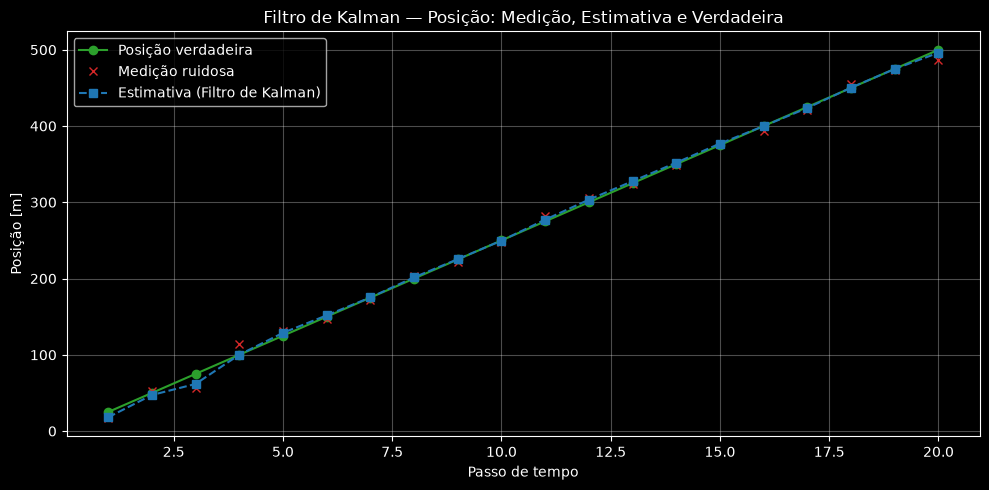

In [6]:
passos = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(passos, pos_verdadeira, "o-", label="Posição verdadeira", color="tab:green")
ax.plot(passos, medicoes, "x", label="Medição ruidosa", color="tab:red", markersize=6)
ax.plot(passos, pos_estimada, "s--", label="Estimativa (Filtro de Kalman)", color="tab:blue")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Posição [m]")
ax.set_title("Filtro de Kalman — Posição: Medição, Estimativa e Verdadeira")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Erro de Posição (Resíduos)

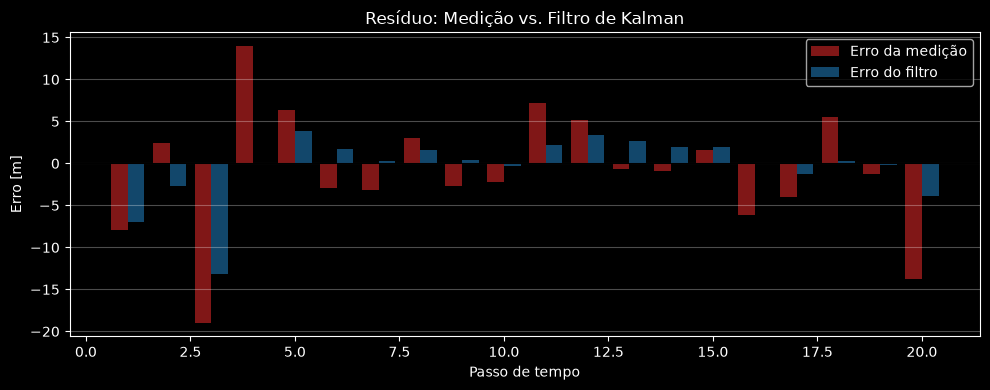

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(passos - 0.2, residuos_med, width=0.4, label="Erro da medição", color="tab:red", alpha=0.6)
ax.bar(passos + 0.2, residuos, width=0.4, label="Erro do filtro", color="tab:blue", alpha=0.6)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Erro [m]")
ax.set_title("Resíduo: Medição vs. Filtro de Kalman")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 7.3 Velocidade Estimada

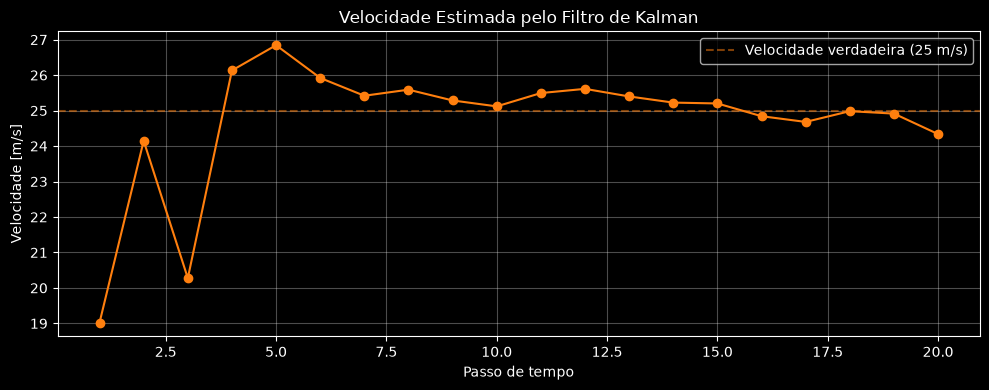

In [8]:
velocidades = historico_x[:, 1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(passos, velocidades, "o-", color="tab:orange")
ax.axhline(y=25.0, color="tab:orange", linestyle="--", alpha=0.5, label="Velocidade verdadeira (25 m/s)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Velocidade [m/s]")
ax.set_title("Velocidade Estimada pelo Filtro de Kalman")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Evolução da Incerteza (Diagonal de $\mathbf{P}$)

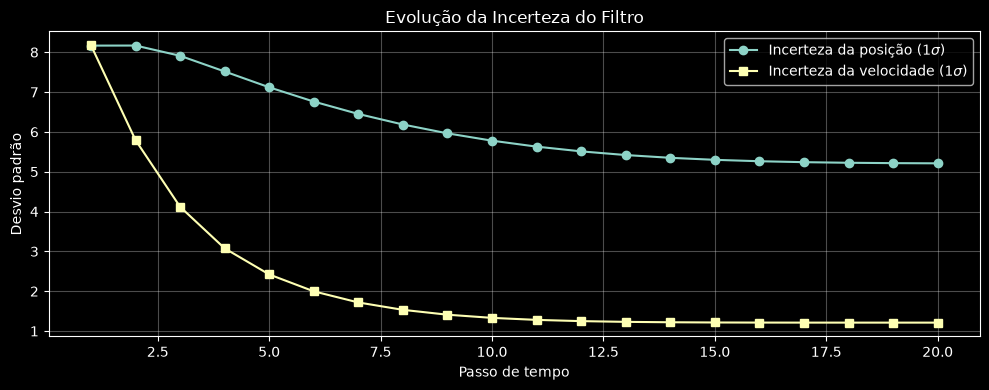

In [9]:
incerteza_pos = np.sqrt(historico_P[:, 0, 0])
incerteza_vel = np.sqrt(historico_P[:, 1, 1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(passos, incerteza_pos, "o-", label=r"Incerteza da posição (1$\sigma$)")
ax.plot(passos, incerteza_vel, "s-", label=r"Incerteza da velocidade (1$\sigma$)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Desvio padrão")
ax.set_title("Evolução da Incerteza do Filtro")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()